In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("delivery_investigation.csv")

In [5]:
df.head()

,order_id,created_at,updated_at,district,restaurant,source_system,transport,weather,distance_km,prep_minutes,courier_load,delivery_minutes,promised_minutes,order_sum,status,rating,courier_id
0,D100001,2026-02-17 11:39:00,2026-02-17 12:24:33,Юг,Taco Point,app,walk,clear,3.28,20.1,1,45.6,39,1 280 ₽,delivered,4.0,C052
1,D100002,2026-02-22 16:42:00,2026-02-22 17:08:46,Центр,Хинкали House,web,car,snow,3.06,4.0,1,26.8,49,890,delivered,5.0,C037
2,D100003,2026-02-01 15:43:00,2026-02-01 15:56:03,Север,Wok Station,partner_api,scooter,clear,11.32,17.0,1,0.0,66,1300,cancelled,NaN,NaN
3,D100004,2026-02-23 12:46:00,2026-02-23 13:26:42,Север,Хинкали House,legacy_csv,bike,rain,5700.0,15.7,2,40.7,52,760,delivered,5.0,C095
4,D100005,2026-02-11 18:30:00,2026-02-11 20:27:59,Запад,Пекарня №7,web,walk,clear,13.65,17.8,3,118.0,75,750,delivered,4.0,C104


In [6]:
df.info

<bound method DataFrame.info of      order_id           created_at           updated_at district  \
0     D100001  2026-02-17 11:39:00  2026-02-17 12:24:33       Юг   
1     D100002  2026-02-22 16:42:00  2026-02-22 17:08:46    Центр   
2     D100003  2026-02-01 15:43:00  2026-02-01 15:56:03    Север   
3     D100004  2026-02-23 12:46:00  2026-02-23 13:26:42    Север   
4     D100005  2026-02-11 18:30:00  2026-02-11 20:27:59    Запад   
...       ...                  ...                  ...      ...   
1273  D100793  2026-02-07 16:02:00  2026-02-07 16:45:49   запад    
1274  D100659  2026-02-06 08:42:00  2026-02-06 09:30:10   север    
1275  D100387  2026-02-24 19:54:00  2026-02-24 20:34:43   север    
1276  D100247  2026-02-05 19:10:00  2026-02-05 19:33:32   север    
1277  D101086  2026-02-09 21:56:00  2026-02-09 22:54:14   север    

             restaurant source_system  transport weather distance_km  \
0            Taco Point           app       walk   clear        3.28   
1         Хинкали House           web        car    snow        3.06   
2           Wok Station   partner_api    scooter   clear       11.32   
3         Хинкали House    legacy_csv       bike    rain      5700.0   
4            Пекарня №7           web       walk   clear       13.65   
...                 ...           ...        ...     ...         ...   
1273        пицца & ко    partner_api      walk    clear        3.41   
1274       wok station    partner_api   scooter    clear        7.21   
1275        taco point            app   scooter    clear        7.78   
1276     хинкали house            app   scooter    clear        2.74   
1277    зелёная кухня             app   scooter    clear        9.19   

      prep_minutes  courier_load  delivery_minutes  promised_minutes  \
0             20.1             1              45.6                39   
1              4.0             1              26.8                49   
2             17.0             1               0.0                66   
3             15.7             2              40.7                52   
4             17.8             3             118.0                75   
...            ...           ...               ...               ...   
1273          20.6             2              43.8                41   
1274          20.1             3            2892.0                43   
1275          13.1             1              40.7                54   
1276          19.5             1              23.5                36   
1277          23.4             2              58.2                62   

     order_sum       status  rating courier_id  
0      1 280 ₽    delivered     4.0       C052  
1          890    delivered     5.0       C037  
2         1300    cancelled     NaN        NaN  
3          760    delivered     5.0       C095  
4          750    delivered     4.0       C104  
...        ...          ...     ...        ...  
1273      1070   delivered      NaN       C091  
1274       850   delivered      4.0       C058  
1275      1050   delivered      NaN       C008  
1276       970   delivered      4.0       C001  
1277      1510   delivered      4.0       C132  

[1278 rows x 17 columns]>

In [7]:
df.shape

(1278, 17)

In [10]:
df.value_counts()

,,,,,,,,,,,,,,,,,count
order_id,created_at,updated_at,district,restaurant,source_system,transport,weather,distance_km,prep_minutes,courier_load,delivery_minutes,promised_minutes,order_sum,status,rating,courier_id,
D101012,2026-02-27 17:25:00,2026-02-27 17:55:33,Центр,Sushi Lab,app,scooter,clear,1.5,16.0,1,30.6,36,820,delivered,4.0,C127,2
D101127,2026-02-16 20:49:00,2026-02-16 21:26:10,Юг,Хинкали House,app,bike,clear,5.9,5.2,2,37.2,53,1140,delivered,5.0,C063,2
D100451,2026-02-15 09:30:00,2026-02-15 09:56:29,Восток,Sushi Lab,app,scooter,clear,2.43,18.5,3,26.5,39,760,delivered,4.0,C056,2
D100809,2026-02-27 15:15:00,2026-02-27 15:49:47,Центр,Пекарня №7,web,scooter,clear,3.14,24.8,1,34.8,39,3180,delivered,4.0,C107,2
D100231,2026-02-17 12:20:00,2026-02-17 12:49:36,Север,SUSHI LAB,app,car,clear,5.47,15.8,3,29.6,45,820,delivered,4.0,C147,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D100411,2026-02-25 18:12:00,2026-02-25 18:58:04,Юг,Бургерная 24,app,walk,snow,1.24,12.6,2,46.1,40,1070,delivered,5.0,C080,1
D100415,2026-02-14 15:24:00,2026-02-14 15:57:46,Восток,Бургерная 24,legacy_csv,car,rain,6460.0,10.6,1,33.8,53,1310,delivered,4.0,C082,1
D100416,2026-02-24 15:17:00,2026-02-24 16:00:41,Юг,Хинкали House,web,walk,rain,3.11,5.4,2,43.7,42,1990,delivered,5.0,C129,1


In [13]:
df.order_id.duplicated()

,order_id
0,False
1,False
2,False
3,False
4,False
...,...
1273,True
1274,True
1275,True
1276,True


In [19]:
df[df.order_id.duplicated()]

,order_id,created_at,updated_at,district,restaurant,source_system,transport,weather,distance_km,prep_minutes,courier_load,delivery_minutes,promised_minutes,order_sum,status,rating,courier_id
1200,D100182,2026-02-01 11:54:00,2026-02-01 12:08:30,Центр,Зелёная кухня,partner_api,car,rain,1.21,22.1,2,NaN,44,670,on_the_way,NaN,C135
1201,D100449,2026-02-02 08:08:00,2026-02-02 08:20:48,Центр,Зелёная кухня,partner_api,bike,clear,1.47,18.4,2,NaN,36,430,preparing,NaN,C023
1202,D100628,2026-02-10 21:26:00,2026-02-10 21:42:40,Запад,Wok Station,partner_api,scooter,rain,2.38,15.8,2,NaN,37,4450,on_the_way,NaN,C054
1203,D100174,2026-02-01 19:02:00,2026-02-01 19:22:39,Восток,Хинкали House,partner_api,scooter,rain,6.68,19.1,3,NaN,55,690,on_the_way,NaN,C083
1204,D100882,2026-02-06 13:28:00,2026-02-06 13:47:53,Восток,Зелёная кухня,web,scooter,rain,6.54,19.8,3,NaN,55,1490,preparing,NaN,C022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,D100793,2026-02-07 16:02:00,2026-02-07 16:45:49,запад,пицца & ко,partner_api,walk,clear,3.41,20.6,2,43.8,41,1070,delivered,NaN,C091
1274,D100659,2026-02-06 08:42:00,2026-02-06 09:30:10,север,wok station,partner_api,scooter,clear,7.21,20.1,3,2892.0,43,850,delivered,4.0,C058
1275,D100387,2026-02-24 19:54:00,2026-02-24 20:34:43,север,taco point,app,scooter,clear,7.78,13.1,1,40.7,54,1050,delivered,NaN,C008
1276,D100247,2026-02-05 19:10:00,2026-02-05 19:33:32,север,хинкали house,app,scooter,clear,2.74,19.5,1,23.5,36,970,delivered,4.0,C001


In [18]:
df[df.order_id == "D100182"]

,order_id,created_at,updated_at,district,restaurant,source_system,transport,weather,distance_km,prep_minutes,courier_load,delivery_minutes,promised_minutes,order_sum,status,rating,courier_id
181,D100182,2026-02-01 11:54:00,2026-02-01 12:26:15,Центр,Зелёная кухня,partner_api,car,rain,1.21,22.1,2,32.3,44,670,delivered,4.0,C135
1200,D100182,2026-02-01 11:54:00,2026-02-01 12:08:30,Центр,Зелёная кухня,partner_api,car,rain,1.21,22.1,2,NaN,44,670,on_the_way,NaN,C135


In [ ]:
import matplotlib.pyplot as plt

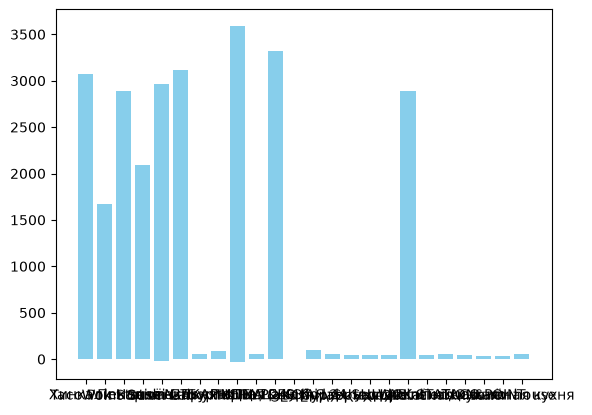

In [ ]:
x = df.order_id
y = df.delivery_minutes
plt.bar(x, y, color='skyblue')
plt.show()